# The hat function: curved failure regions and an exact polynomial check

The hat function appears in the benchmark list of [Moustapha, Marelli and Sudret (2022)](https://doi.org/10.1016/j.strusafe.2021.102174). We use the explicit **UQLab 2.2.0 example definition**, with an independent reference integral. It complements the structural [truss tutorial](ex_literature_truss.ipynb) and the existing four-branch problem.

There is a source discrepancy worth preserving: Table 3 of the review supplement lists $4.40\times10^{-3}$ for the hat function, whereas the definition below gives $3.8654\times10^{-4}$. The [provenance note](../literature-benchmarks.rst) records this and the possible, unconfirmed transposition with the four-branch entry. This tutorial does **not** claim to reproduce that printed probability.

Keep `literature_benchmarks.py` beside this notebook. The code requires PySTRA, NumPy and SciPy; the bootstrap-PCE method does not need the optional Kriging dependency.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import pystra as ra
from pystra.active_learning import (
    ActiveLearning, PceSurrogate, AllCriteria, BetaBounds, BetaStability,
)
from literature_benchmarks import (
    truss_model, truss_deflection, truss_limit_state, truss_reference,
    hat_model, hat_limit_state, hat_reference,
)

## Definition and an independent integral

Let $X_1,X_2$ be independent $N(0.25,1)$ variables, where 1 is the standard deviation, and define

$$g(X_1,X_2)=20-(X_1-X_2)^2-8(X_1+X_2-4)^3.$$

Failure means $g\leq0$. Introduce $S=(X_1+X_2)/\sqrt{2}$ and $D=(X_1-X_2)/\sqrt{2}$. Then $S\sim N(0.5/\sqrt{2},1)$ and $D\sim N(0,1)$ independently. Since the cubic is monotone,

$$P_f=\int_{-\infty}^\infty \phi(d)\,\bar\Phi\left(
\frac{4+\sqrt[3]{(20-2d^2)/8}-0.5}{\sqrt{2}}\right)\,\mathrm{d}d.$$

Use the **real cube root**, including when its argument is negative. Quadrature splits at $d=\pm\sqrt{10}$, where the cube-root derivative is singular. Truncating the normal integral to $[-10,10]$ omits less than $1.6\times10^{-23}$ of probability mass.

Quadrature Pf: 0.000386539808628; beta: 3.362258


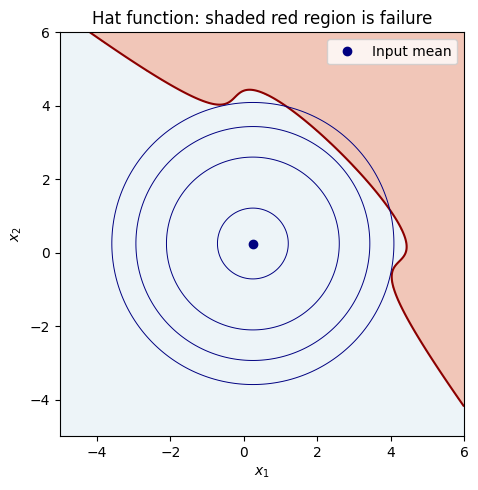

In [2]:
reference = hat_reference()
print(f"Quadrature Pf: {reference:.12g}; beta: {-norm.ppf(reference):.6f}")
axis = np.linspace(-5, 6, 350)
x1, x2 = np.meshgrid(axis, axis)
response = hat_limit_state(x1, x2)
fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(x1, x2, response <= 0, levels=[-0.5, 0.5, 1.5],
            colors=["#edf4f8", "#f1c6b8"])
ax.contour(x1, x2, response, levels=[0], colors="darkred")
density = norm.pdf(x1, loc=0.25) * norm.pdf(x2, loc=0.25)
ax.contour(x1, x2, density, levels=[1e-4, 1e-3, 0.01, 0.1], colors="navy", linewidths=0.7)
ax.plot(0.25, 0.25, "o", color="navy", label="Input mean")
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="Hat function: shaded red region is failure")
ax.set_aspect("equal")
ax.legend()
fig.tight_layout()
plt.show()

## Local approximations

FORM and SORM describe the failure boundary near one design point. Compare their approximations with the integral before choosing a surrogate or a simulation method.

In [3]:
model = hat_model()
state = ra.LimitState(hat_limit_state)
form = ra.Form(model, state)
form_result = form.run()
sorm = ra.Sorm(model, state, form=form)
sorm.run()
assert form_result.converged and sorm.results_valid
pd.DataFrame([
    {"Method": "Quadrature", "Pf": reference},
    {"Method": "FORM", "Pf": form_result.failure_probability},
    {"Method": "SORM (Breitung)", "Pf": float(sorm.pf2_breitung)},
]).set_index("Method")

,Pf
Method,
Quadrature,0.000387
FORM,0.000292
SORM (Breitung),0.000330


## A polynomial diagnostic

The independent normal transformation is affine here, so the limit state remains a degree-three polynomial in standard coordinates. A complete cubic Hermite basis can represent it exactly. Check predictions at independent points over a wider domain than the training cloud; this isolates polynomial fitting from probability estimation.

In [4]:
rng = np.random.default_rng(913)
training = rng.normal(size=(60, 2))
surrogate = PceSurrogate(degree=3, method="ols", seed=4)
surrogate.fit(training, hat_limit_state(*(training + 0.25).T))
query = rng.uniform(-5, 5, size=(2000, 2))
expected = hat_limit_state(*(query + 0.25).T)
predicted, spread = surrogate.predict(query)
print(f"Maximum absolute response error: {np.max(np.abs(expected - predicted)):.3g}")
np.testing.assert_allclose(predicted, expected, rtol=1e-11, atol=1e-9)

Maximum absolute response error: 2.82e-11


## Adaptive sparse PCE with an independent final sample

Now let the adaptive algorithm select the polynomial degree. Its beta-band and beta-stability rules measure surrogate convergence; a separate criterion checks final sampling precision. Exact polynomial representability makes this case particularly favourable to PCE. It does not establish similar accuracy for nonsmooth minima, discontinuities or arbitrary structural response functions.

In [5]:
seed = 7
analysis = ActiveLearning(
    stochastic_model=hat_model(), limit_state=ra.LimitState(hat_limit_state),
    surrogate=PceSurrogate(degree=(1, 2, 3, 4, 5), max_interaction=2, seed=seed),
    n_initial=30, n_candidates=12_000, n_estimation=400_000,
    max_iterations=180, seed=seed,
    stopping_criterion=AllCriteria(criteria=(
        BetaBounds(consecutive=2), BetaStability(consecutive=2),
    )),
)
result = analysis.run()
print(f"Status: {result.status}; true model calls: {result.n_evaluations}")
print(f"Selected degree: {analysis.surrogate_model.fit_result.degree}")
print(f"Pf: {result.failure_probability:.7f}; sampling CoV: {result.sampling_cov:.3f}")
print(f"95% interval conditional on the surrogate: {result.sampling_interval}")
assert result.converged
assert abs(result.failure_probability - reference) < (
    4 * np.sqrt(reference * (1 - reference) / result.n_estimation) + 0.05 * reference
)

Status: converged; true model calls: 32
Selected degree: 3
Pf: 0.0003750; sampling CoV: 0.082
95% interval conditional on the surrogate: (0.00031739914988147784, 0.00044002860349804014)


Even an exact surrogate produces a fluctuating Monte Carlo estimate. Its sampling interval concerns the frozen approximation; in a general problem it does not certify surrogate accuracy. Tests also check the reference using independent two-dimensional importance sampling and repeat the adaptive analysis with three seeds.

Together with the truss and four-branch tutorials, this gives smooth structural response, an exactly representable curved polynomial, and a nonsmooth multiple-region problem. The two reviews provide the broader method context: [Moustapha et al. (2022)](https://doi.org/10.1016/j.strusafe.2021.102174) and [Teixeira, Nogal and O’Connor (2021)](https://doi.org/10.1016/j.strusafe.2020.102019).